**Forecasting Country-wise Tourist Arrivals to Sri Lanka Using Economic and Climate Indicators.**




In [ ]:
#import libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Explainability
import shap
from sklearn.inspection import PartialDependenceDisplay

import joblib


Load dataset

In [ ]:
#import dataset
df=pd.read_csv("/content/touristData.csv")
df.head()



,year,month,originCountry,totalCount,dollarRate,apparent_temperature_mean_celcius,sunshine_duration_seconds,rain_sum_mm,precipitation_hours,num_establishments,num_rooms,AirPassengerFaresIndex,consumerPriceIndex
0,2024,January,India,34399,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,185.5
1,2024,January,Russia,31159,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,251.3
2,2024,January,United Kingdom,16665,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,130.0
3,2024,January,Germany,13593,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,117.6
4,2024,January,China,11511,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,103.1


In [ ]:
df.describe()

,year,totalCount,dollarRate,apparent_temperature_mean_celcius,sunshine_duration_seconds,rain_sum_mm,precipitation_hours,num_establishments,num_rooms,AirPassengerFaresIndex,consumerPriceIndex
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,2021.120000,8621.441333,246.605333,29.279963,33570.295600,6.008511,7.797062,3495.320000,46494.480000,174.862667,134.335778
std,2.086001,9127.986128,74.757200,0.669481,2278.424351,2.004730,1.349833,860.378253,6854.116363,13.358923,42.809533
min,2018.000000,10.000000,153.900000,28.228086,28159.767720,2.075309,4.222222,2121.000000,35397.000000,140.800000,73.235850
25%,2019.000000,2613.500000,179.900000,28.723765,31987.295150,4.783333,6.651235,2620.000000,40365.000000,167.600000,104.305000
50%,2021.000000,5700.000000,200.920000,29.189506,33666.409040,6.179630,7.910494,3656.000000,47337.000000,177.000000,118.515000
75%,2023.000000,10807.500000,317.000000,29.616358,35063.090900,7.485494,8.796296,4346.000000,53229.000000,184.200000,143.998760
max,2024.000000,52881.000000,368.500000,30.940741,38963.963890,10.306481,10.845679,4519.000000,55455.000000,202.900000,331.870000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               750 non-null    int64  
 1   month                              750 non-null    object 
 2   originCountry                      750 non-null    object 
 3   totalCount                         750 non-null    int64  
 4   dollarRate                         750 non-null    float64
 5   apparent_temperature_mean_celcius  750 non-null    float64
 6   sunshine_duration_seconds          750 non-null    float64
 7   rain_sum_mm                        750 non-null    float64
 8   precipitation_hours                750 non-null    float64
 9   num_establishments                 750 non-null    int64  
 10  num_rooms                          750 non-null    int64  
 11  AirPassengerFaresIndex             750 non-null    float64

Preprocessing

In [ ]:
month_map = {
    "January":1, "February":2, "March":3, "April":4,
    "May":5, "June":6, "July":7, "August":8,
    "September":9, "October":10, "November":11, "December":12
}

df["month"] = df["month"].map(month_map)


In [ ]:
#create date column
df["date"] = pd.to_datetime(df[["year","month"]].assign(day=1))

df = df.sort_values("date")
df.head()

,year,month,originCountry,totalCount,dollarRate,apparent_temperature_mean_celcius,sunshine_duration_seconds,rain_sum_mm,precipitation_hours,num_establishments,num_rooms,AirPassengerFaresIndex,consumerPriceIndex,date
638,2018,1,Ukraine,6636,153.9,29.275926,34796.17889,4.943519,7.280864,2121,35397,187.7,243.300000,2018-01-01
637,2018,1,United States,7501,153.9,29.275926,34796.17889,4.943519,7.280864,2121,35397,187.7,113.671519,2018-01-01
636,2018,1,Australia,9452,153.9,29.275926,34796.17889,4.943519,7.280864,2121,35397,187.7,112.600000,2018-01-01
635,2018,1,Russia,11569,153.9,29.275926,34796.17889,4.943519,7.280864,2121,35397,187.7,170.104700,2018-01-01
634,2018,1,France,12221,153.9,29.275926,34796.17889,4.943519,7.280864,2121,35397,187.7,101.750000,2018-01-01


In [ ]:
#Lag features
df["lag_1"] = df.groupby("originCountry")["totalCount"].shift(1)
df["lag_2"] = df.groupby("originCountry")["totalCount"].shift(2)
df["lag_3"] = df.groupby("originCountry")["totalCount"].shift(3)

df["rolling_mean_3"] = (
    df.groupby("originCountry")["totalCount"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

df = df.dropna()
df.head()

,year,month,originCountry,totalCount,dollarRate,apparent_temperature_mean_celcius,sunshine_duration_seconds,rain_sum_mm,precipitation_hours,num_establishments,num_rooms,AirPassengerFaresIndex,consumerPriceIndex,date,lag_1,lag_2,lag_3,rolling_mean_3
666,2018,4,France,7411,157.6,29.253395,35487.30448,3.619753,6.58642,2121,35397,182.0,102.920000,2018-04-01,14818.0,16871.0,12221.0,10382.000000
664,2018,4,Germany,10803,157.6,29.253395,35487.30448,3.619753,6.58642,2121,35397,182.0,97.807790,2018-04-01,24423.0,17066.0,15298.0,15493.333333
665,2018,4,United States,8679,157.6,29.253395,35487.30448,3.619753,6.58642,2121,35397,182.0,114.900106,2018-04-01,9701.0,5984.0,7501.0,16314.000000
662,2018,4,China,17462,157.6,29.253395,35487.30448,3.619753,6.58642,2121,35397,182.0,94.221150,2018-04-01,21101.0,35929.0,24275.0,18408.333333
661,2018,4,United Kingdom,26063,157.6,29.253395,35487.30448,3.619753,6.58642,2121,35397,182.0,105.500000,2018-04-01,30366.0,23817.0,22940.0,20389.333333


In [ ]:
#encode the categorical features
le = LabelEncoder()

df["originCountry"] = le.fit_transform(df["originCountry"])

In [ ]:
X = df.drop(columns=["totalCount", "date"])
y = df["totalCount"]


Train/Test Split

In [ ]:
split_date = "2023-01-01"

X_train = X[df["date"] < split_date]
X_test  = X[df["date"] >= split_date]

y_train = y[df["date"] < split_date]
y_test  = y[df["date"] >= split_date]


Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Model Training — XGBoost

In [ ]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_scaled, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#predictions
y_pred = model.predict(X_test_scaled)


Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 3420.86962890625
RMSE: 5306.732893221591
R2  : 0.6692631244659424


In [ ]:
print("Train R2:", model.score(X_train_scaled, y_train))
print("Test R2:", model.score(X_test_scaled, y_test))

Train R2: 0.9997562170028687
Test R2: 0.6692631244659424


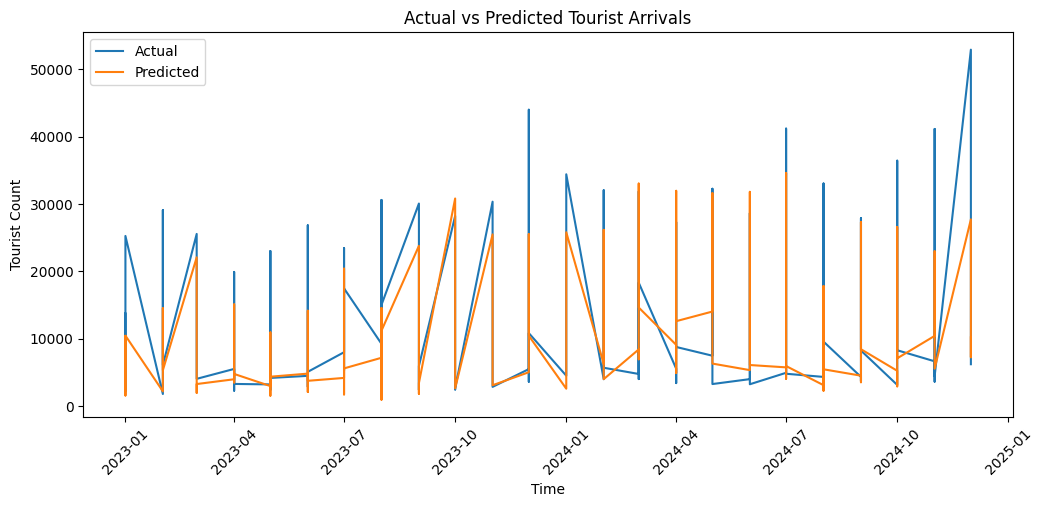

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df.loc[y_test.index, "date"], y_test, label="Actual")
plt.plot(df.loc[y_test.index, "date"], y_pred, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Tourist Arrivals")
plt.xlabel("Time")
plt.ylabel("Tourist Count")
plt.xticks(rotation=45)

plt.show()



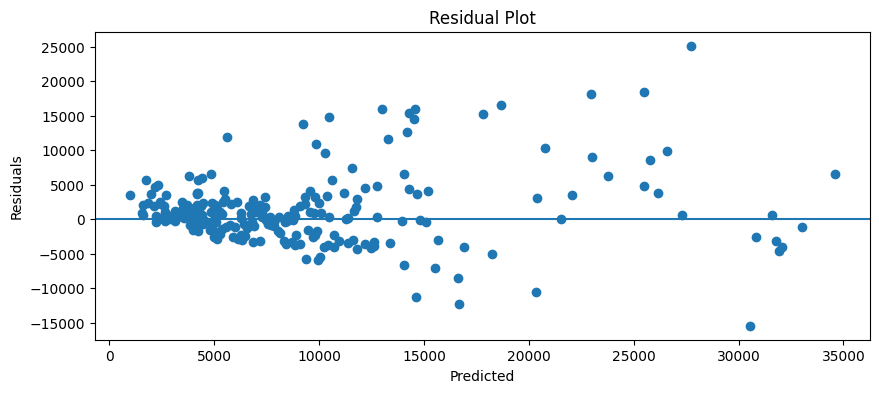

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10,4))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()


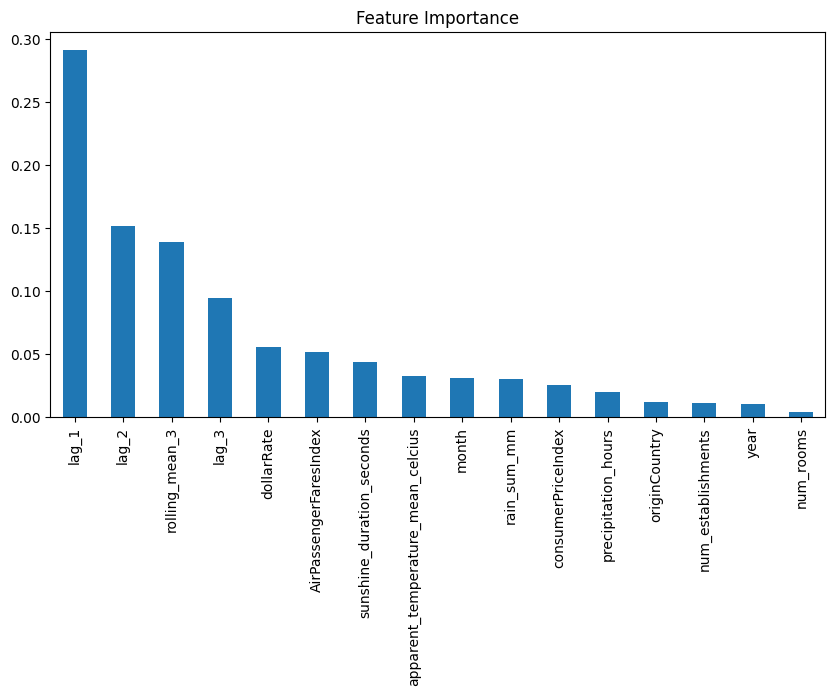

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()


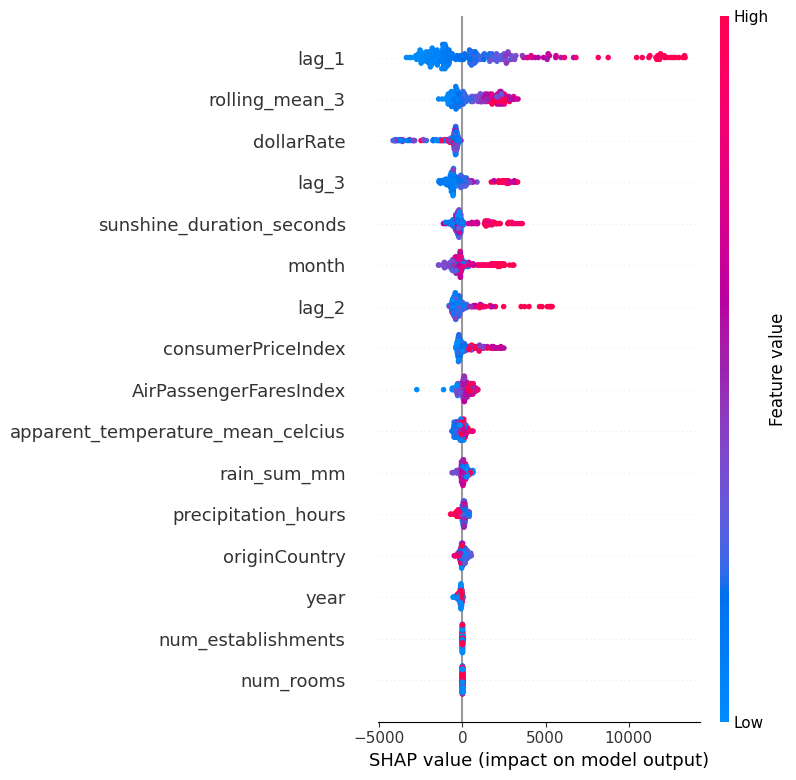

In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test, show=False)
plt.show()


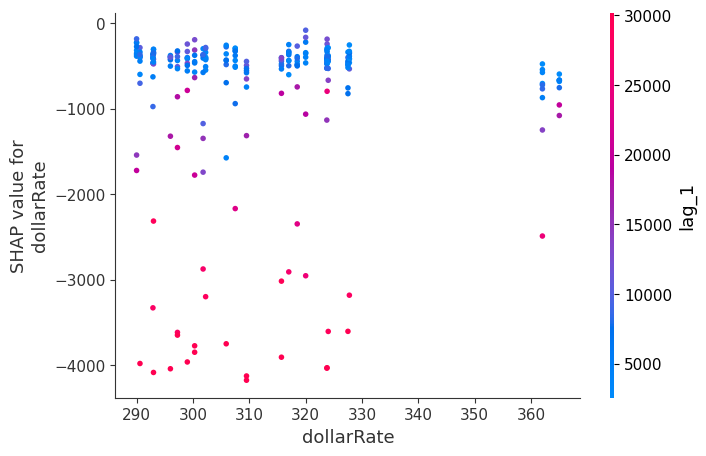

In [ ]:
shap.dependence_plot(
    "dollarRate",
    shap_values.values,
    X_test
)


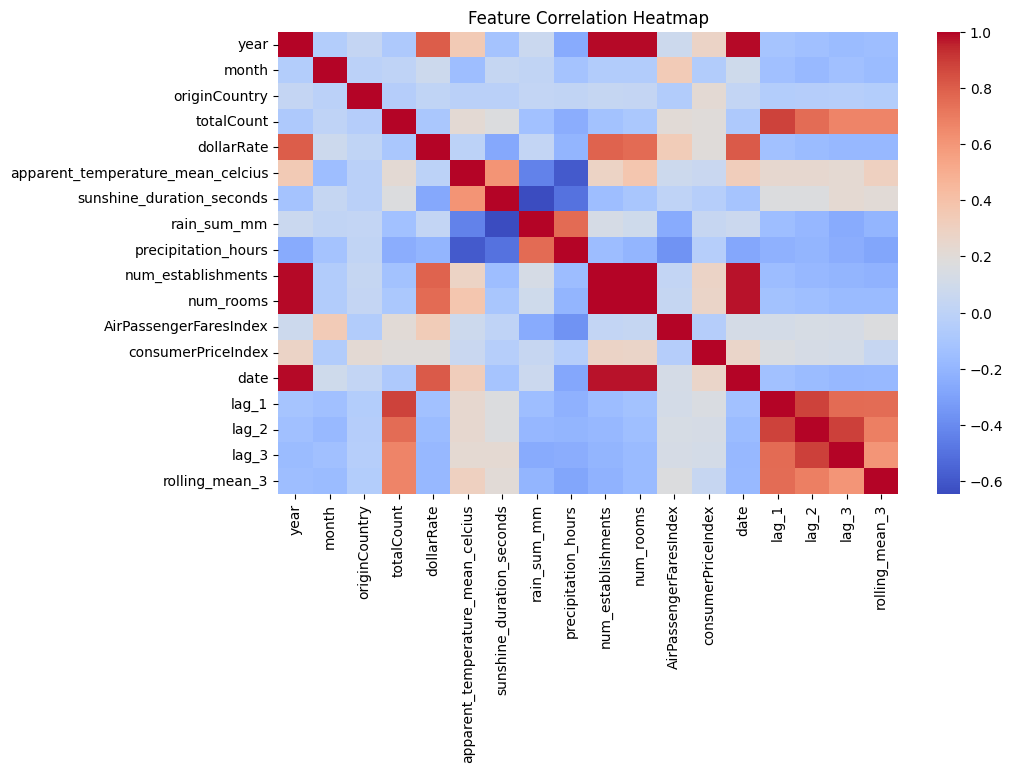

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


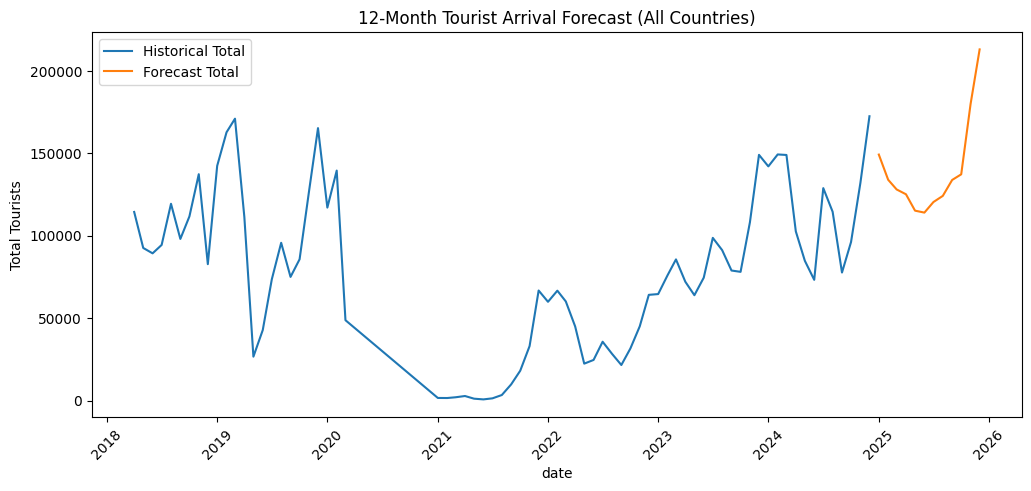

In [ ]:
future_dates = pd.date_range(
    start=df["date"].max() + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

all_countries = df["originCountry"].unique()
future_forecast_list = []

for country in all_countries:

    # Get last known data for this country
    country_data = df[df["originCountry"] == country].copy()
    last_row = country_data.iloc[-1]

    lags = [
        last_row["lag_1"],
        last_row["lag_2"],
        last_row["lag_3"]
    ]

    rolling_vals = lags.copy()

    for date in future_dates:
        row = {}
        row["year"] = date.year
        row["month"] = date.month
        row["originCountry"] = country

        row["dollarRate"] = last_row["dollarRate"]
        row["apparent_temperature_mean_celcius"] = last_row["apparent_temperature_mean_celcius"]
        row["sunshine_duration_seconds"] = last_row["sunshine_duration_seconds"]
        row["rain_sum_mm"] = last_row["rain_sum_mm"]
        row["precipitation_hours"] = last_row["precipitation_hours"]
        row["num_establishments"] = last_row["num_establishments"]
        row["num_rooms"] = last_row["num_rooms"]
        row["AirPassengerFaresIndex"] = last_row["AirPassengerFaresIndex"]
        row["consumerPriceIndex"] = last_row["consumerPriceIndex"]

        # Lag features
        row["lag_1"] = lags[0]
        row["lag_2"] = lags[1]
        row["lag_3"] = lags[2]
        row["rolling_mean_3"] = np.mean(rolling_vals)

        # Predict
        row_df = pd.DataFrame([row])
        row_scaled = scaler.transform(row_df[X.columns])
        pred = model.predict(row_scaled)[0]
        row["forecast"] = pred

        # Append to forecast list
        future_forecast_list.append(row)

        # Update lags for next month
        lags = [pred, lags[0], lags[1]]
        rolling_vals = lags.copy()

# Combine all future rows
future_df = pd.DataFrame(future_forecast_list)

# Create the 'date' column in future_df
future_df["date"] = pd.to_datetime(future_df[["year", "month"]].assign(day=1))

# Decode country names back
future_df["originCountry"] = le.inverse_transform(future_df["originCountry"].astype(int))


total_forecast = future_df.groupby("date")["forecast"].sum()
historical_total = df.groupby("date")["totalCount"].sum()


plt.figure(figsize=(12,5))
plt.plot(historical_total.index, historical_total.values, label="Historical Total")
plt.plot(total_forecast.index, total_forecast.values, label="Forecast Total")
plt.legend()
plt.title("12-Month Tourist Arrival Forecast (All Countries)")
plt.xlabel("date")
plt.ylabel("Total Tourists")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# import joblib

# # Save model
# joblib.dump(model, "model.pkl")

# # Save scaler
# joblib.dump(scaler, "scaler.pkl")

# # Save label encoder
# joblib.dump(le, "label_encoder.pkl")

# # Save feature column order (VERY IMPORTANT)
# joblib.dump(X.columns.tolist(), "feature_columns.pkl")

In [ ]:
# from google.colab import files

# files.download("model.pkl")
# files.download("scaler.pkl")
# files.download("label_encoder.pkl")
# files.download("feature_columns.pkl")